Q1. Write a function Reservior Temperature(depth m, Surface temp-4.0, gradient= 30.0) that returns temperature in degree celcius. including docstring, type hints and input validation.

In [12]:
def reservoir_temperature(
    depth_m: float,
    surface_temp: float = 4.0,
    gradient: float = 30.0,
) -> float:
    """Calculate reservoir temperature from depth in metres.

    The geothermal gradient is in °C per kilometre.
    """
    for name, value in (
        ("depth_m", depth_m),
        ("surface_temp", surface_temp),
        ("gradient", gradient),
    ):
        if isinstance(value, bool) or not isinstance(value, (int, float)):
            raise TypeError(f"{name} must be a number")

    if depth_m < 0:
        raise ValueError("depth_m cannot be negative")

    if gradient < 0:
        raise ValueError("gradient cannot be negative")

    depth_km = depth_m / 1000
    return surface_temp + gradient * depth_km

# Example usage after defining the function
depth_m_example = 2000.0
result = reservoir_temperature(depth_m_example, surface_temp=4.0, gradient=30.0)
print(f"The reservoir temperature at {depth_m_example}m is {result:.2f}°C")

The reservoir temperature at 2000.0m is 64.00°C


The type hints document the expected inputs and output. The checks reject non numeric values and negative depth. A negative geothermal gradient is also rejected here because this exercise models temperature increasing with depth. eg. if print(reservoir_temperature(1000)). At 1,000 m, the default calculation is 4.0 + 30.0 × 1 = 34.0 °C. This function estimates reservoir temperature from well depth using a surface temperature of 4°C and a geothermal gradient of 30°C per kilometre by default. It validates the inputs and reports an error if the depth or gradient is negative, or if an input is not numeric.

Q2. Read a CSV file (well_depths.csv) containing 50 well depth measurements and calculate temperatures for all wells using your function

In [30]:
import pandas as pd
import numpy as np

data_to_generate = {
    'well_id': range(1, 51),
    'depth_m': np.random.uniform(500, 3000, 50).round(2)
}
generated_df = pd.DataFrame(data_to_generate)
generated_df.to_csv('well_depths.csv', index=False)
print("Generated 'well_depths.csv' with 50 random depth entries.")

depths = pd.read_csv("well_depths.csv")

if "depth_m" not in depths.columns:
    raise ValueError("The CSV must contain a column named 'depth_m'")

depths["depth_m"] = pd.to_numeric(depths["depth_m"], errors="raise")

depths["temperature_c"] = depths["depth_m"].apply(reservoir_temperature)

display(depths.head(50))

Generated 'well_depths.csv' with 50 random depth entries.


,well_id,depth_m,temperature_c
0,1,2570.29,81.1087
1,2,1588.00,51.6400
2,3,1059.11,35.7733
3,4,2264.40,71.9320
4,5,716.29,25.4887
5,6,707.38,25.2214
6,7,2499.44,78.9832
7,8,804.50,28.1350
8,9,923.76,31.7128
9,10,2434.18,77.0254


The CSV file contains the well depth measurements. I load the data, check that it has a depth_m column, convert the values to numbers, and apply the temperature function to calculate a temperature for each well.

Q3. Create a scatter plot showing temperature vs. depth with a linear trendline. Label axes with units, add a title, and include the trendline equation in the legend.

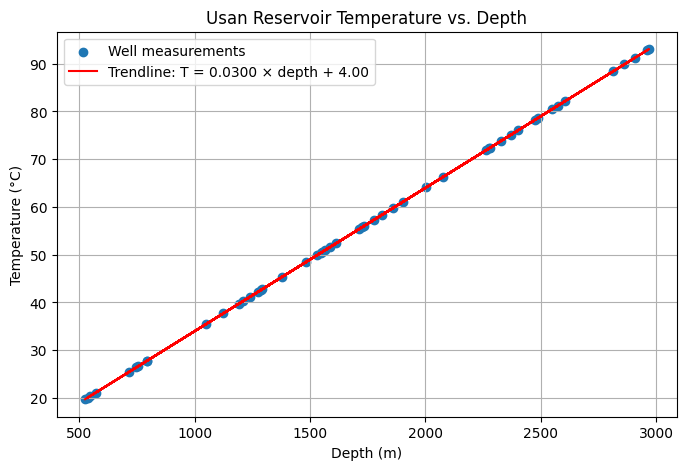

In [20]:
import numpy as np
import matplotlib.pyplot as plt

x = depths["depth_m"]
y = depths["temperature_c"]

slope, intercept = np.polyfit(x, y, 1)
trendline = slope * x + intercept

plt.figure(figsize=(8, 5))
plt.scatter(x, y, label="Well measurements")
plt.plot(
    x,
    trendline,
    color="red",
    label=f"Trendline: T = {slope:.4f} × depth + {intercept:.2f}",
)

plt.xlabel("Depth (m)")
plt.ylabel("Temperature (°C)")
plt.title("Usan Reservoir Temperature vs. Depth")
plt.legend()
plt.grid(True)
plt.show()

This scatter plot shows calculated temperature against well depth. The line is a linear trendline fitted to the data, and its equation is included in the legend. Depth is shown in metres and temperature in degrees Celsius.

Q4. Add error handling for negative depths and non-numeric inputs. Write at least 3 test cases that verify correct behaviour for both valid and invalid inputs

In [21]:
assert reservoir_temperature(0) == 4.0
assert reservoir_temperature(1000) == 34.0

assert reservoir_temperature(2000, surface_temp=5.0, gradient=25.0) == 55.0

try:
    reservoir_temperature(-100)
except ValueError as error:
    print("Correctly rejected negative depth:", error)
else:
    raise AssertionError("Negative depth should have been rejected")

try:
    reservoir_temperature("deep")
except TypeError as error:
    print("Correctly rejected non-numeric depth:", error)
else:
    raise AssertionError("Non-numeric depth should have been rejected")

Correctly rejected negative depth: depth_m cannot be negative
Correctly rejected non-numeric depth: depth_m must be a number


These tests check that the function returns expected results for valid inputs and rejects invalid inputs, including a negative depth and a non numeric depth.